# S7 · Commented solution — import the licensing table

**Release this notebook after the exercise.** The target is page 1 of `docs/column_separators.pdf`. We preserve the raw output, reconstruct one row per licence, and compare difficult entries with the source.

In [1]:
from pathlib import Path
import camelot
import pandas as pd

# Locate docs/ whether the notebook runs in the course folder or notebooks/.
here = Path.cwd()
ROOT = next((p for p in [here, here.parent, here / "S7_course_material_REVISED"]
             if (p / "docs" / "column_separators.pdf").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open S7_course_material_REVISED or its notebooks/ folder.")
SOURCE = ROOT / "docs" / "column_separators.pdf"
print("Source:", SOURCE.name)

Source: column_separators.pdf


## 1 · See the source and diagnose the first attempt

The page has report text and ten licence fields. Blue background stripes are visual formatting; they do not create a table grid that Lattice can rely on.

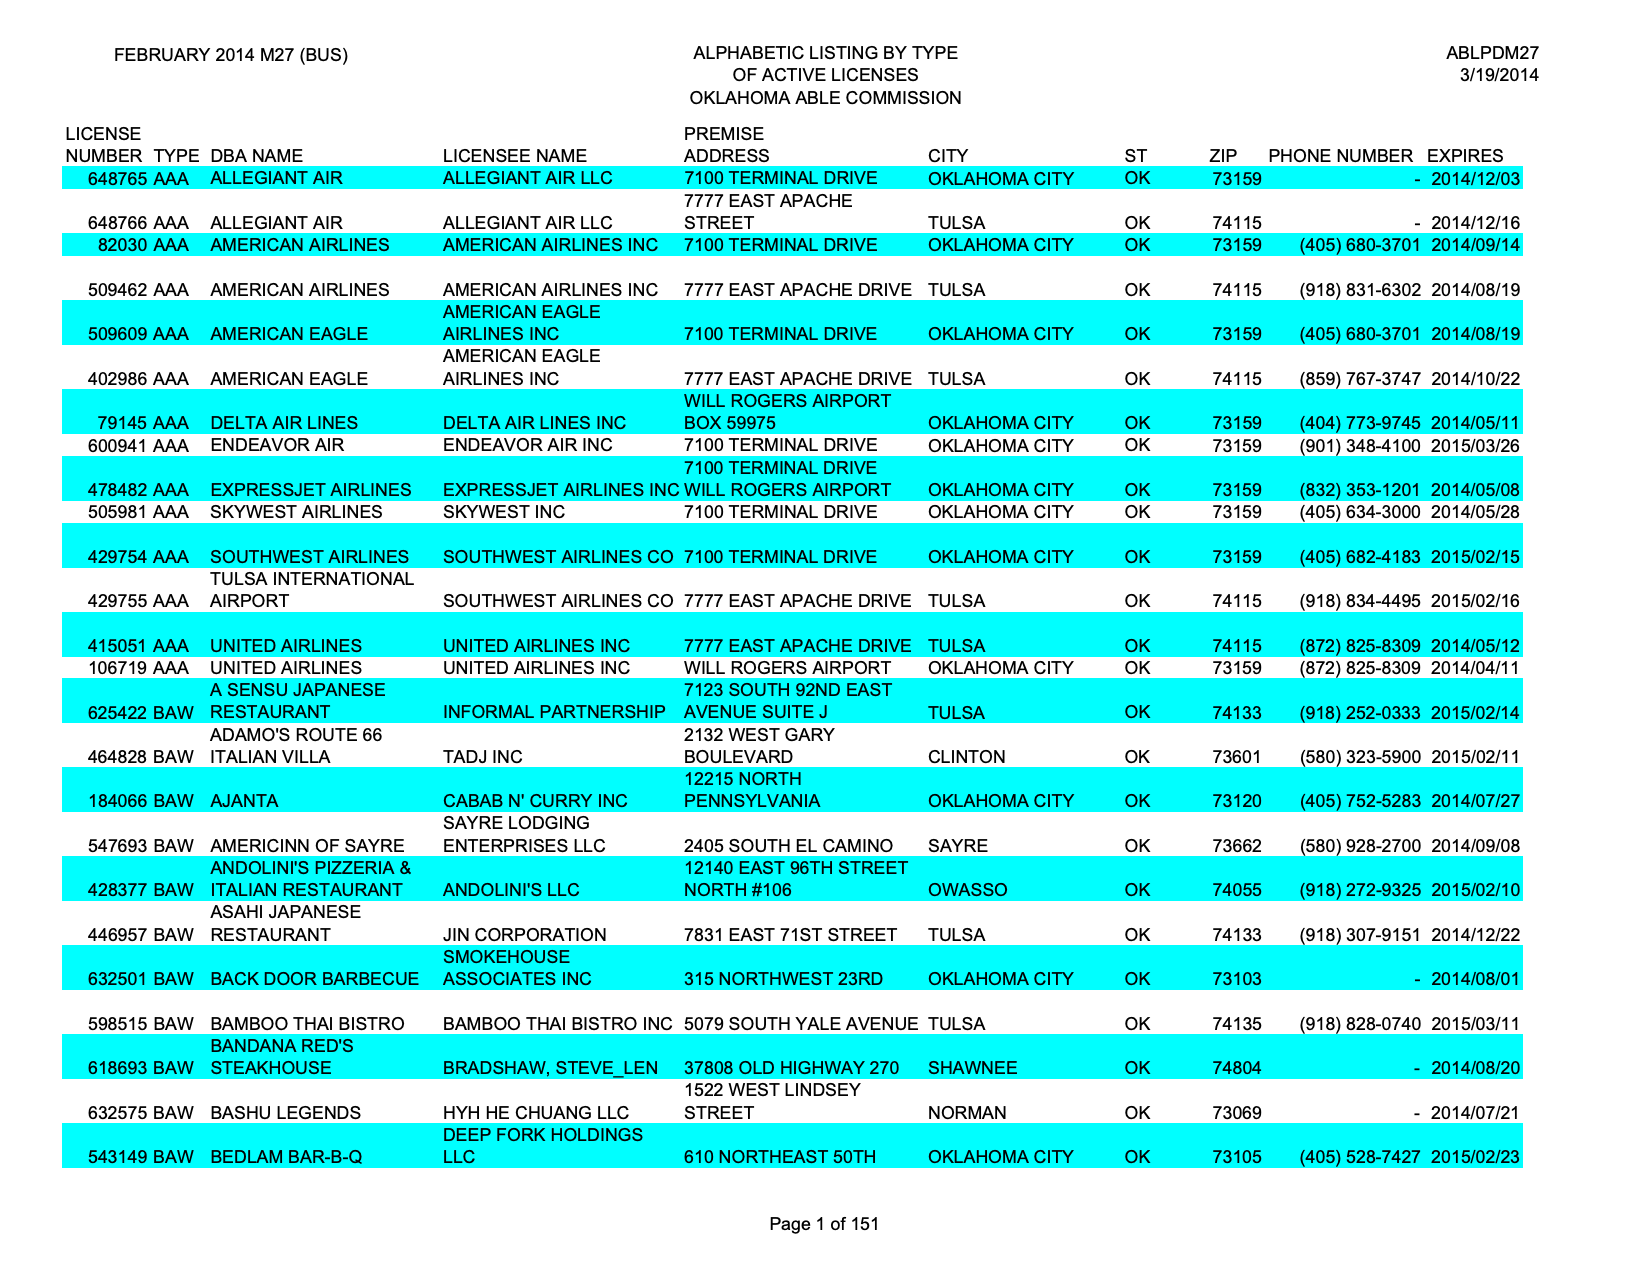

Page 1: 792 × 612 PDF points


In [2]:
import pdfplumber
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.patches import Rectangle
from IPython.display import display

# Display page 1 and read its actual PDF dimensions.
with pdfplumber.open(SOURCE) as document:
    page = document.pages[0]
    page_width, page_height = page.width, page.height
    page_image = page.to_image(resolution=150).original
    display(page_image)

print(f"Page 1: {page_width:g} × {page_height:g} PDF points")

In [3]:
# Lattice looks for ruling lines, which this page does not provide.
lattice = camelot.read_pdf(str(SOURCE), pages="1", flavor="lattice")
print("Lattice candidates:", len(lattice))
for candidate in lattice:
    print("Shape:", candidate.df.shape)
    display(candidate.df.head(7))

Lattice candidates: 0


In [4]:
# Keep the first Stream attempt as evidence of the automatic grouping.
stream = camelot.read_pdf(str(SOURCE), pages="1", flavor="stream")
print("Stream candidates:", len(stream))
assert len(stream) > 0, "No Stream candidate: inspect the PDF before plotting."
print("Initial Stream shape:", stream[0].df.shape)
display(stream[0].df.head(7))

Stream candidates: 1
Initial Stream shape: (46, 6)


,0,1,2,3,4,5
0,FEBRUARY 2014 M27 (BUS),,,,,
1,,OF ACTIVE LICENSES,,,,3/19/2014
2,,OKLAHOMA ABLE COMMISSION,,,,
3,LICENSE,PREMISE,,,,
4,NUMBER TYPE DBA NAME,LICENSEE NAME\nADDRESS\nCITY,ST,ZIP,PHONE NUMBER,EXPIRES
5,648765 AAA,ALLEGIANT AIR ALLEGIANT AIR...,OK,73159,-,2014/12/03
6,,7777 EAST APACHE,,,,


## 2 · Locate and verify the column separators

`camelot.plot(..., kind="text")` shows the source page and the positions of its text objects. Read the horizontal **x axis** to locate the gaps between printed fields. The coordinates use the PDF page space, with **(0, 0) at the bottom left** and y increasing upward. This page measures **792 × 612 PDF points**. Image pixels depend on rendering resolution and must not be used directly as PDF coordinates.

First inspect the text plot without our chosen separators. Major x ticks occur every 50 points, with minor ticks every 25. In VS Code the plot normally appears inside the notebook. An interactive Matplotlib backend may also show cursor coordinates.

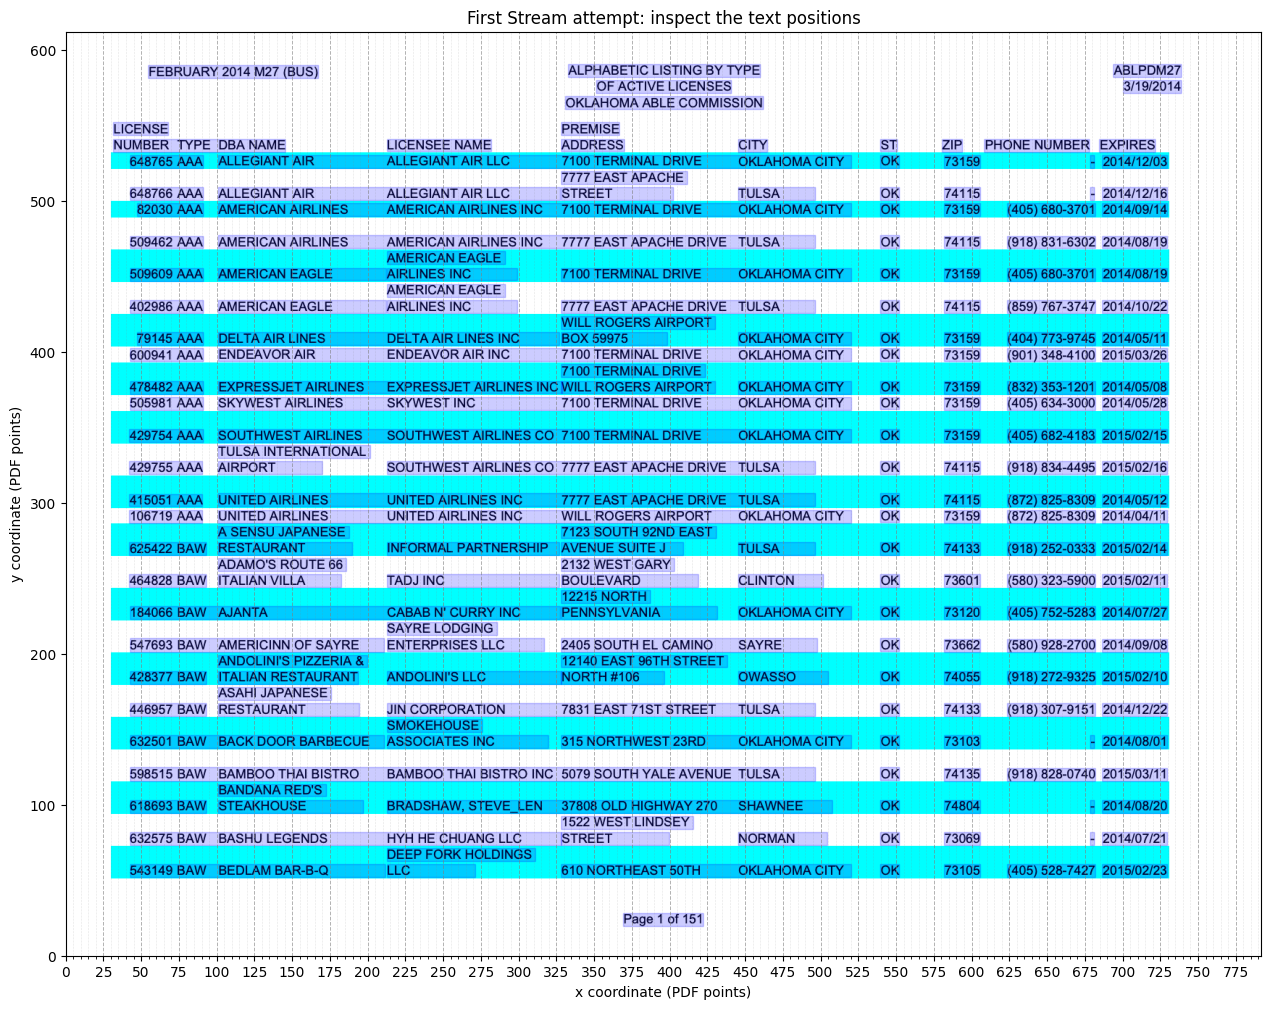

In [14]:
import pdfplumber

# Load the original page and its dimensions.
with pdfplumber.open(SOURCE) as document:
    page = document.pages[0]
    page_width = page.width
    page_height = page.height
    page_image = page.to_image(resolution=150).original

# Configure the figure returned by Camelot, rather than an unrelated plt.figure().
fig = camelot.plot(stream[0], kind="text")
fig.set_size_inches(18, 12)
ax = fig.axes[0]
# Keep the original page visible, including on versions that plot only text boxes.
for background in list(ax.images):
    background.remove()
ax.imshow(page_image, extent=(0, page_width, 0, page_height), origin="upper", zorder=0)
ax.set_xlim(0, page_width)
ax.set_ylim(0, page_height)
ax.xaxis.set_major_locator(MultipleLocator(25))
ax.xaxis.set_minor_locator(MultipleLocator(5))
ax.grid(axis="x", which="major", color="grey", linestyle="--", linewidth=0.7, alpha=0.6)
ax.grid(axis="x", which="minor", color="grey", linestyle=":", linewidth=0.4, alpha=0.4)
ax.set_xlabel("x coordinate (PDF points)")
ax.set_ylabel("y coordinate (PDF points)")
ax.set_title("First Stream attempt: inspect the text positions")
plt.show()

### The choices used in this solution

Nine internal separators delimit **ten printed fields**. Read them from left to right:

| x coordinate | Between these fields |
|---:|---|
| 72 | Licence number / Licence type |
| 95 | Licence type / DBA name |
| 209 | DBA name / Licensee name |
| 327 | Licensee name / Premise address |
| 442 | Premise address / City |
| 529 | City / State |
| 566 | State / ZIP code |
| 606 | ZIP code / Phone |
| 683 | Phone / Expiry date |

The green rectangle selects **data lines only**, below the column headings and above the page number. Its bounds are **left=30, top=532, right=738, bottom=48**. A horizontal or vertical heading can span a separator, so inspect data values as well as headings.

These coordinates are specific to this PDF and also appear in Camelot's [official advanced example](https://camelot-py.readthedocs.io/en/stable/user/advanced.html#specify-column-separators). They are reference choices to verify against the page, not automatically discovered boundaries.

In [6]:
# One shared set of coordinates drives both the overlay and the extraction.
x_separators = [72, 95, 209, 327, 442, 529, 566, 606, 683]
left, top, right, bottom = 30, 532, 738, 48

assert 0 <= left < right <= page_width
assert 0 <= bottom < top <= page_height
assert x_separators == sorted(x_separators)
assert all(left < x < right for x in x_separators)

# Camelot expects comma-separated coordinate strings inside lists.
separators = ",".join(str(x) for x in x_separators)
data_area = f"{left},{top},{right},{bottom}"
print("columns:", [separators])
print("table_areas:", [data_area])

columns: ['72,95,209,327,442,529,566,606,683']
table_areas: ['30,532,738,48']


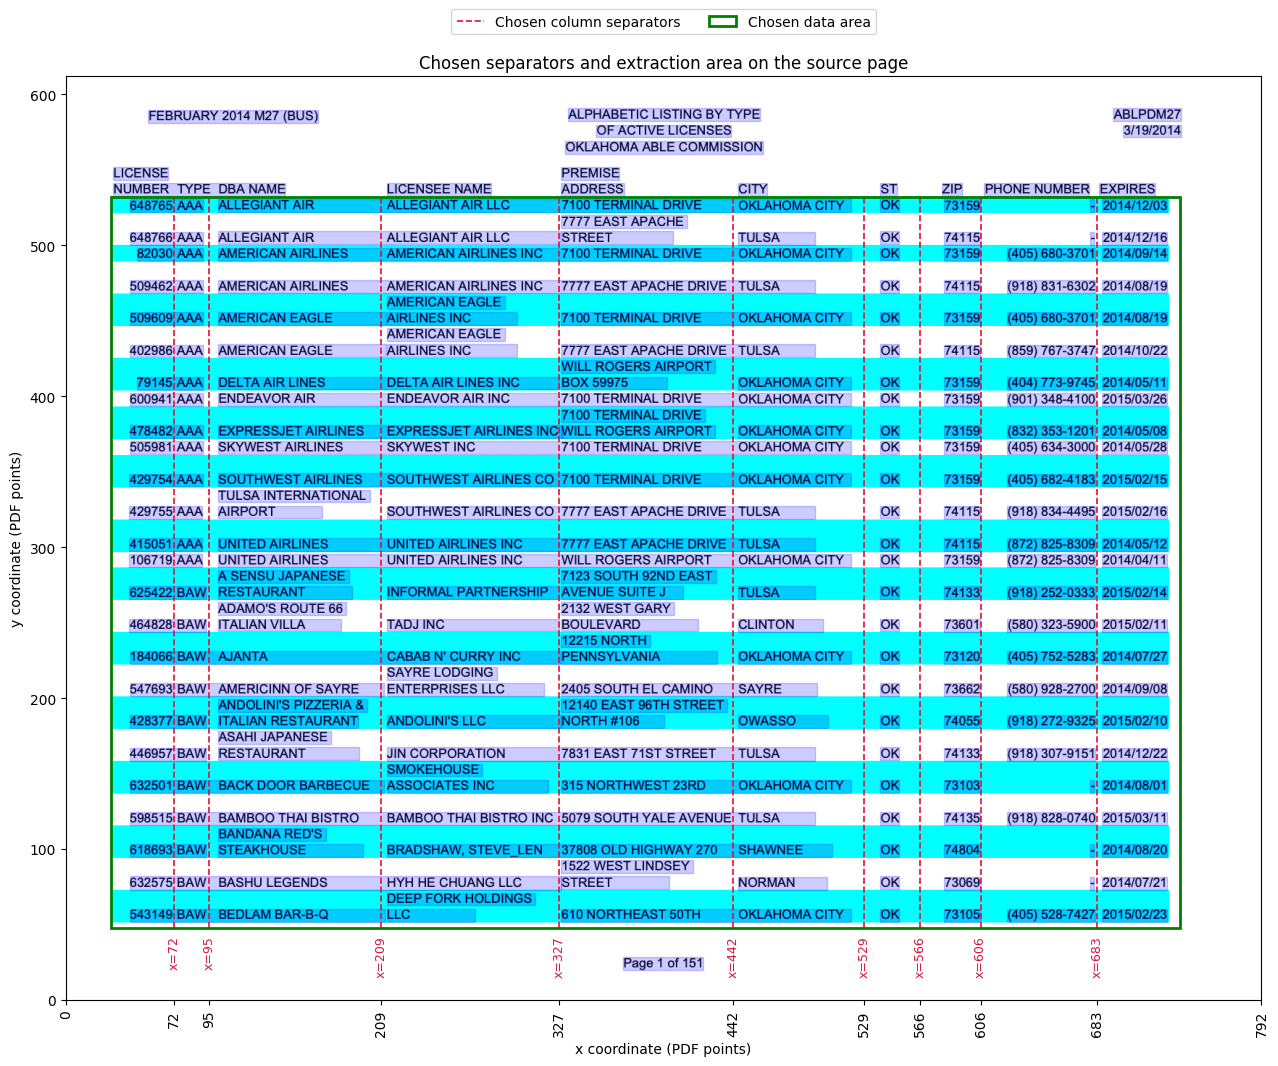

In [16]:
# Overlay our proposed boundaries on the source page before extraction.
fig = camelot.plot(stream[0], kind="text")
fig.set_size_inches(18, 12)
ax = fig.axes[0]
# Use the same original page image beneath Camelot's text boxes.
for background in list(ax.images):
    background.remove()
ax.imshow(page_image, extent=(0, page_width, 0, page_height), origin="upper", zorder=0)

# Red lines show the nine internal cuts within the selected data area.
ax.vlines(x_separators, bottom, top, color="crimson", linewidth=1.2,
          linestyles="--", label="Chosen column separators", zorder=5)
for x in x_separators:
    ax.text(x, bottom - 5, f"x={x}", rotation=90, ha="center", va="top",
            fontsize=9, color="crimson", zorder=6, clip_on=True)

# The green frame shows the exact rectangle sent to table_areas.
ax.add_patch(Rectangle((left, bottom), right - left, top - bottom,
                       fill=False, edgecolor="green", linewidth=2,
                       label="Chosen data area", zorder=5))
ax.set_xlim(0, page_width)
ax.set_ylim(0, page_height)
ax.set_xticks([0, *x_separators, page_width])
ax.tick_params(axis="x", labelrotation=90)
ax.set_xlabel("x coordinate (PDF points)")
ax.set_ylabel("y coordinate (PDF points)")
ax.set_title("Chosen separators and extraction area on the source page")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=2)
plt.show()

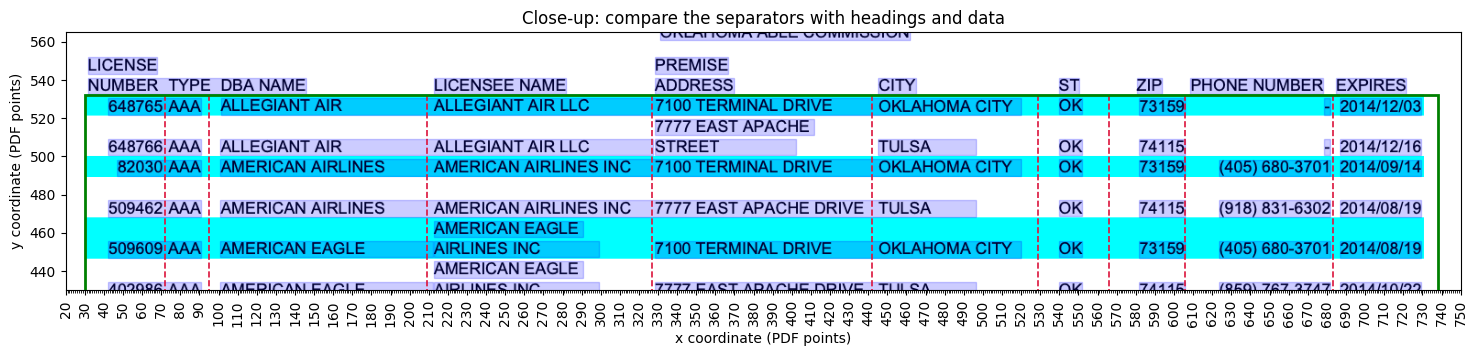

In [17]:
# Reuse the same annotated figure for a close-up of the headings and first entries.
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(1))
fig.set_size_inches(18, 5)
ax.set_xlim(20, 750)
ax.set_ylim(430, 565)
ax.set_title("Close-up: compare the separators with headings and data")
ax.get_legend().remove()
display(fig)
plt.close(fig)

### Apply the visually checked settings

`columns` supplies the separators. `table_areas` limits the extraction to the green rectangle. `split_text=True` splits text objects that cross cell boundaries. The headings sit outside our selected data area, so we assign clear field names later.

After extraction, inspect the raw rows. Correct separator positions do not automatically assemble names or addresses wrapped across several lines.

In [18]:
# Use exactly the coordinates shown in the overlay, on page 1 only.
selected = camelot.read_pdf(
    str(SOURCE),
    pages="1",
    flavor="stream",
    columns=[separators],
    table_areas=[data_area],
    split_text=True
)
assert len(selected) == 1, "Inspect any changed source or parser version."
raw = selected[0].df.copy()
assert raw.shape[1] == 10, "Inspect the printed fields and separators."
print("Raw candidate shape:", raw.shape)
print("Parser report:", selected[0].parsing_report)
display(raw.head(9))

Raw candidate shape: (41, 10)
Parser report: {'accuracy': 87.78, 'whitespace': 34.39, 'order': 1, 'page': 1}


,0,1,2,3,4,5,6,7,8,9
0,648765,AAA,ALLEGIANT AIR,ALLEGIANT AIR LLC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,-,2014/12/03
1,,,,,7777 EAST APACHE,,,,,
2,648766,AAA,ALLEGIANT AIR,ALLEGIANT AIR LLC,STREET,TULSA,OK,74115,-,2014/12/16
3,82030,AAA,AMERICAN AIRLINES,AMERICAN AIRLINES INC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,(405) 680-3701,2014/09/14
4,509462,AAA,AMERICAN AIRLINES,AMERICAN AIRLINES INC,7777 EAST APACHE DRIVE,TULSA,OK,74115,(918) 831-6302,2014/08/19
5,,,,AMERICAN EAGLE,,,,,,
6,509609,AAA,AMERICAN EAGLE,AIRLINES INC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,(405) 680-3701,2014/08/19
7,,,,AMERICAN EAGLE,,,,,,
8,402986,AAA,AMERICAN EAGLE,AIRLINES INC,7777 EAST APACHE DRIVE,TULSA,OK,74115,(859) 767-3747,2014/10/22


## 3 · Interpret wrapped lines before forming records

A licence number starts a record. With this PDF, a name or address sometimes starts on the printed line **before** the licence-number baseline. Such continuation fragments occur as rows with an empty first cell in Camelot's raw table. We hold them until the *following* numbered row. This rule is confirmed against the page, not inferred from a parser score.

In [19]:
import re

fields = ["license_number", "license_type", "dba_name", "licensee_name",
          "premise_address", "city", "state", "zip_code", "phone", "expires"]
records = []
pending = []
for raw_row in raw.itertuples(index=False, name=None):
    cells = [str(cell).strip() for cell in raw_row]
    # Match a printed licence identifier, not the report title or page number.
    if re.fullmatch(r"\d{5,6}", cells[0]):
        # Attach preceding wrapped fragments to the record that follows them.
        assembled = [" ".join(part for part in
                      [*(fragment[j] for fragment in pending), cells[j]] if part)
                     for j in range(len(fields))]
        records.append(assembled)
        pending = []
    elif any(cells):
        # Keep the unnumbered line; it can contain a wrapped name or address.
        pending.append(cells)
assert not pending, "Unassigned trailing text needs a page check."
licenses = pd.DataFrame(records, columns=fields)
display(licenses)

,license_number,license_type,dba_name,licensee_name,premise_address,city,state,zip_code,phone,expires
0,648765,AAA,ALLEGIANT AIR,ALLEGIANT AIR LLC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,-,2014/12/03
1,648766,AAA,ALLEGIANT AIR,ALLEGIANT AIR LLC,7777 EAST APACHE STREET,TULSA,OK,74115,-,2014/12/16
2,82030,AAA,AMERICAN AIRLINES,AMERICAN AIRLINES INC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,(405) 680-3701,2014/09/14
3,509462,AAA,AMERICAN AIRLINES,AMERICAN AIRLINES INC,7777 EAST APACHE DRIVE,TULSA,OK,74115,(918) 831-6302,2014/08/19
4,509609,AAA,AMERICAN EAGLE,AMERICAN EAGLE AIRLINES INC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,(405) 680-3701,2014/08/19
5,402986,AAA,AMERICAN EAGLE,AMERICAN EAGLE AIRLINES INC,7777 EAST APACHE DRIVE,TULSA,OK,74115,(859) 767-3747,2014/10/22
6,79145,AAA,DELTA AIR LINES,DELTA AIR LINES INC,WILL ROGERS AIRPORT BOX 59975,OKLAHOMA CITY,OK,73159,(404) 773-9745,2014/05/11
7,600941,AAA,ENDEAVOR AIR,ENDEAVOR AIR INC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,(901) 348-4100,2015/03/26
8,478482,AAA,EXPRESSJET AIRLINES,EXPRESSJET AIRLINES INC,7100 TERMINAL DRIVE WILL ROGERS AIRPORT,OKLAHOMA CITY,OK,73159,(832) 353-1201,2014/05/08
9,505981,AAA,SKYWEST AIRLINES,SKYWEST INC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,(405) 634-3000,2014/05/28


## 4 · Validate row grain, column placement and wrapped examples

There are 25 visible licence numbers on page 1. Keep ZIP and licence numbers as strings. Phone `-` is the printed placeholder and is not a telephone number; its business meaning is unknown here, so the raw value stays visible.

In [11]:
assert licenses.shape == (25, 10)
assert licenses.license_number.is_unique
assert licenses.license_number.str.fullmatch(r"\d{5,6}").all()
assert licenses.zip_code.str.fullmatch(r"\d{5}").all()
assert set(licenses.license_type) == {"AAA", "BAW"}
assert licenses.loc[licenses.license_number.eq("648766"), "premise_address"].item() == "7777 EAST APACHE STREET"
assert licenses.loc[licenses.license_number.eq("429755"), "dba_name"].item() == "TULSA INTERNATIONAL AIRPORT"
assert licenses.loc[licenses.license_number.eq("509609"), "licensee_name"].item() == "AMERICAN EAGLE AIRLINES INC"
assert licenses.loc[licenses.license_number.eq("632575"), "premise_address"].item() == "1522 WEST LINDSEY STREET"
print("Data records:", len(licenses), "fields:", len(licenses.columns))
print("Unique licences:", licenses.license_number.nunique())
print("Empty strings by field:")
print(licenses.eq("").sum())
display(licenses.loc[licenses.license_number.isin(["648766", "429755", "509609", "632575"])])

Data records: 25 fields: 10
Unique licences: 25
Empty strings by field:
license_number     0
license_type       0
dba_name           0
licensee_name      0
premise_address    0
city               0
state              0
zip_code           0
phone              0
expires            0
dtype: int64


,license_number,license_type,dba_name,licensee_name,premise_address,city,state,zip_code,phone,expires
1,648766,AAA,ALLEGIANT AIR,ALLEGIANT AIR LLC,7777 EAST APACHE STREET,TULSA,OK,74115,-,2014/12/16
4,509609,AAA,AMERICAN EAGLE,AMERICAN EAGLE AIRLINES INC,7100 TERMINAL DRIVE,OKLAHOMA CITY,OK,73159,(405) 680-3701,2014/08/19
11,429755,AAA,TULSA INTERNATIONAL AIRPORT,SOUTHWEST AIRLINES CO,7777 EAST APACHE DRIVE,TULSA,OK,74115,(918) 834-4495,2015/02/16
23,632575,BAW,BASHU LEGENDS,HYH HE CHUANG LLC,1522 WEST LINDSEY STREET,NORMAN,OK,73069,-,2014/07/21


## 5 · Export and state the limits

The PDF is a 151-page original report, but the supplied sample has two pages; the exercise extracts **page 1 only**. These checks establish row grain and spot-check several wrapped fields. They do not certify all 250 individual cells: a full publication workflow should compare every cell or use a validated reference source.

In [12]:
# Save the result beside the notebooks, creating the output folder if needed.
output = ROOT / "notebooks" / "S7_student_exercise_page1_solution.csv"
output.parent.mkdir(parents=True, exist_ok=True)
licenses.to_csv(output, index=False, encoding="utf-8")
print("Saved:", output.name)

Saved: S7_student_exercise_page1_solution.csv


**Result.** Page 1 yields a DataFrame of **25 licence entries × 10 fields**. `lattice` yields no table; unadjusted `stream` includes report text and mixes columns. Explicit separators, an area and `split_text=True` yield a usable raw candidate; wrapped rows require a documented, page-specific decision. Source: Camelot's [official advanced usage documentation](https://camelot-py.readthedocs.io/en/stable/user/advanced.html#specify-column-separators) and the supplied PDF.